In [3]:
#1. import the tools
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
print("All tools imported successfully")

All tools imported successfully


In [4]:
#2. load the dataset
num_words = 30000
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

#3. print the shapes
print("Training data shape (reviews):", len(x_train))
print("Training data shape (labels):", len(y_train))
print("Testing data shape (reviews):", len(x_test))
print("Testing data shape (labels):", len(y_test))
print("\nFirst 5 training labels:", y_train[:5])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape (reviews): 25000
Training data shape (labels): 25000
Testing data shape (reviews): 25000
Testing data shape (labels): 25000

First 5 training labels: [1 0 0 1 0]


In [6]:
#4. look at the first review
print("First review (as number): ")
print(x_train[0])
print("\nLength of first review:", len(x_train[0]))

First review (as number): 
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

Length of fi

In [9]:
#5. get the word index (the dictionary that maps words to numbers)
word_index = keras.datasets.imdb.get_word_index()

#6. Reverse the dictionary (number -> word)
reverse_word_index = {value: key for key, value in word_index.items()}

#7. function to decode a review
def decode_review(encoded_review):
  #the imdb dataset uses offset 3 for special tokens
  return ' '.join([reverse_word_index.get(i -3, '?')for i in encoded_review])

#8. decode and print the first review
print("first review (as words):")
print(decode_review(x_train[0]))

first review (as words):
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are a

In [11]:
#9. pad the sequences to make them all the same length
maxlen = 500
x_train_padded = keras.preprocessing.sequence.pad_sequences(x_train,maxlen)
x_test_padded = keras.preprocessing.sequence.pad_sequences(x_test,maxlen)

print("Training data shape (padded):", x_train_padded.shape)
print("Testing data shape (padded):", x_test_padded.shape)

#10. look at the first padded review
print("\nFirst review (padded, first 10 mubers): ")
print(x_train_padded[0][:10])
print("\nFirst review (padded, last 10 mubers): ")
print(x_train_padded[0][-10:])

Training data shape (padded): (25000, 500)
Testing data shape (padded): (25000, 500)

First review (padded, first 10 mubers): 
[0 0 0 0 0 0 0 0 0 0]

First review (padded, last 10 mubers): 
[4472  113  103   32   15   16 5345   19  178   32]


In [15]:
#11. build the neural network
model = keras.Sequential([
    #embedding layer: 10,000 words -> 16-dimensional vectors
    keras.layers.Embedding(input_dim=num_words,output_dim=16),

    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(16,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
    ])
#12. print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
#13. compile the model
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
print("Model comipled successfully")

Model comipled successfully


In [18]:
#14. train the model
history = model.fit(x_train_padded, y_train, epochs=10, batch_size=512, validation_split=0.2)
print("\nTraning completed!")

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5209 - loss: 0.6917 - val_accuracy: 0.5198 - val_loss: 0.6907
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.5411 - loss: 0.6857 - val_accuracy: 0.6988 - val_loss: 0.6761
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.6916 - loss: 0.6647 - val_accuracy: 0.6056 - val_loss: 0.6533
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7181 - loss: 0.6316 - val_accuracy: 0.7634 - val_loss: 0.6082
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7462 - loss: 0.5886 - val_accuracy: 0.7836 - val_loss: 0.5614
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7964 - loss: 0.5340 - val_accuracy: 0.8060 - val_loss: 0.5092
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8263 - loss: 0.4804 - val_accuracy: 0.8224 - val_loss: 0.4658
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8329 - loss: 0.4382 - val_accuracy: 0.8408 - v

In [19]:
#15. evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test_padded, y_test)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy * 100: .2f}%")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8383 - loss: 0.3970

Test loss: 0.3970
Test accuracy:  83.83%


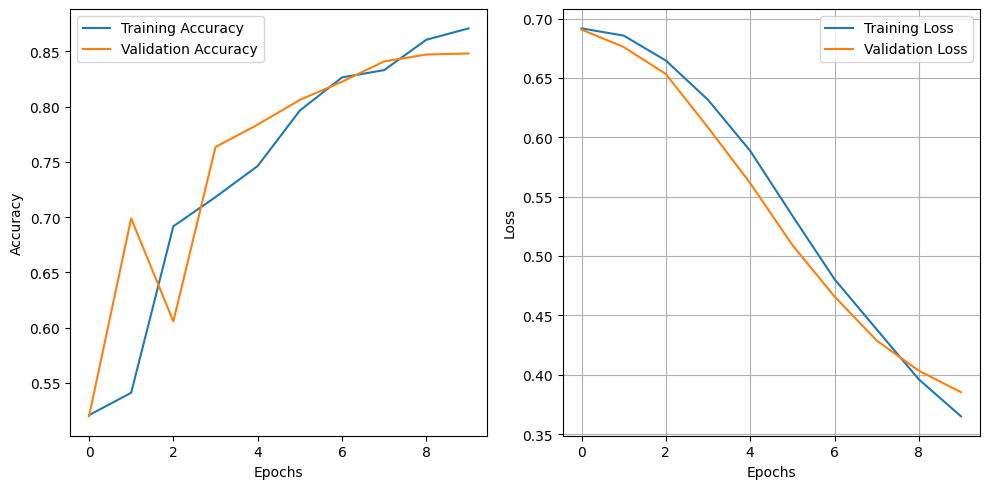

In [20]:
#16. plot training history
plt.figure(figsize=(10,5))

#plot training & validation accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#plot training & validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
#17. function to convert text to numbers
def text_to_numbers(text):
  #get the word index
  word_index = keras.datasets.imdb.get_word_index()
  #covert text to lowercase and slipt into words
  words = text.lower().split()
  #covert each word to its number (if it exists in the vocabulary)
  #the IMDB dataset uses offset 3
  numbers=[]
  for word in words:
    if word in word_index:
      #add 3 because of IMBD offset
      numbers.append(word_index[word] + 3)
    else:
      #unknown word
      numbers.append(2) #2 is the code for unknown
  return numbers

#18. fuction to predict sentiment
def predict_sentiment(text):
  #convert text to numbers
  numbers = text_to_numbers(text)

  #pad the sequence
  padded = keras.preprocessing.sequence.pad_sequences([numbers], maxlen=maxlen)

  #make prediction
  prediction = model.predict(padded)[0][0]

  #return sentiment
  if prediction > 0.5:
    return f"positive (confidence: {prediction * 100: .2f}%)"
  elif prediction < 0.5:
    return f"negative (confidence: {(1 - prediction) *100:.2f}%)"

In [27]:
#19. test with custom reviews
print("--Testing with custom reviews---\n")
review1 = "This movie was amazing! I loved every minute of it. The acting was brilliant and the story was captivating."
print(f"Review: {review1}")
print(f"Sentiment: {predict_sentiment(review1)}\n")
review2 = "This movie was terrible. I wasted my time. The acting was horrible and the plot made no sense."
print(f"Review: {review2}")
print(f"Sentiment: {predict_sentiment(review2)}\n")
review3 = "This film was okay. Some parts were good, some parts were boring. I'm not sure if i would recommend it."
print(f"Review: {review3}")
print(f"Sentiment: {predict_sentiment(review3)}\n")

--Testing with custom reviews---

Review: This movie was amazing! I loved every minute of it. The acting was brilliant and the story was captivating.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Sentiment: negative (confidence: 60.52%)

Review: This movie was terrible. I wasted my time. The acting was horrible and the plot made no sense.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Sentiment: negative (confidence: 77.62%)

Review: This film was okay. Some parts were good, some parts were boring. I'm not sure if i would recommend it.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Sentiment: negative (confidence: 69.45%)



In [28]:
#20. test with your own review
my_review = input("Write a movie review: ")
print(f"\nYour Review: {my_review}")
print(f"Sentiment: {predict_sentiment(my_review)}")

Write a movie review: The movie was too good. 

Your Review: The movie was too good. 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Sentiment: negative (confidence: 62.66%)
